***Importing the libraries***

In [1]:
import warnings
warnings.filterwarnings('ignore')  

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
tf.logging.set_verbosity(tf.logging.ERROR)
from tensorflow.examples.tutorials.mnist import input_data
import matplotlib.pyplot as plt
%matplotlib inline

***Loading the MNIST dataset***

In [2]:
mnist = input_data.read_data_sets('data/mnist', one_hot=True) 

Extracting data/mnist\train-images-idx3-ubyte.gz
Extracting data/mnist\train-labels-idx1-ubyte.gz
Extracting data/mnist\t10k-images-idx3-ubyte.gz
Extracting data/mnist\t10k-labels-idx1-ubyte.gz


***Defining helper functions***

In [3]:
def initialize_weights(shape):
    return tf.Variable(tf.truncated_normal(shape, stddev=0.1))

In [4]:
def initialize_bias(shape):
    return tf.Variable(tf.constant(0.1, shape=shape))

In [5]:
def convolution(x, W):
    return tf.nn.conv2d(x, W, strides=[1,1,1,1], padding='SAME')

In [6]:
def max_pooling(x):
    return tf.nn.max_pool(x, ksize=[1,2,2,1], strides=[1,2,2,1], padding='SAME')

***Defining placeholders for input and output***

In [7]:
X_ = tf.placeholder(tf.float32, [None, 784])

In [8]:
X = tf.reshape(X_, [-1, 28, 28, 1])

In [9]:
y = tf.placeholder(tf.float32, [None, 10])

***Defining the Convolutional Network***

In [10]:
W1 = initialize_weights([5,5,1,32])

In [11]:
b1 = initialize_bias([32])

In [12]:
conv1 = tf.nn.relu(convolution(X, W1) + b1)
pool1 = max_pooling(conv1)

***Defining second convolutional and pooling layer***

In [13]:
W2 = initialize_weights([5,5,32,64])

In [14]:
b2 = initialize_bias([64])

In [15]:
conv2 = tf.nn.relu(convolution(pool1, W2) + b2)
pool2 = max_pooling(conv2)

In [16]:
flattened = tf.reshape(pool2, [-1, 7*7*64])

In [17]:
W_fc = initialize_weights([7*7*64, 1024])
b_fc = initialize_bias([1024])

In [18]:
fc_output = tf.nn.relu(tf.matmul(flattened, W_fc) + b_fc)

In [19]:
W_out = initialize_weights([1024, 10])
b_out = initialize_bias([10])

In [20]:
y_hat = tf.nn.softmax(tf.matmul(fc_output, W_out) + b_out)

***Computing loss***

In [21]:
cross_entropy = -tf.reduce_sum(y*tf.log(y_hat))

In [22]:
optimizer = tf.train.AdamOptimizer(1e-4).minimize(cross_entropy)

In [23]:
predicted_digit = tf.argmax(y_hat, 1)
actual_digit = tf.argmax(y, 1)

correct_pred = tf.equal(predicted_digit,actual_digit)
accuracy = tf.reduce_mean(tf.cast(correct_pred, tf.float32))

***Training the CNN***

In [24]:
sess = tf.Session()
sess.run(tf.global_variables_initializer())

In [25]:
for epoch in range(1000):
    
    #select some batch of data points according to the batch size (100)
    X_batch, y_batch = mnist.train.next_batch(batch_size=100)
    
    #train the network
    loss, acc,  _ = sess.run([cross_entropy, accuracy, optimizer], feed_dict={X_: X_batch, y: y_batch})
    
    #print the loss on every 100th epoch
    if epoch%100 == 0:
        print('Epoch: {}, Loss:{} Accuracy: {}'.format(epoch,loss,acc))

Epoch: 0, Loss:596.76611328125 Accuracy: 0.10999999940395355
Epoch: 100, Loss:48.05537796020508 Accuracy: 0.8399999737739563
Epoch: 200, Loss:31.963640213012695 Accuracy: 0.8799999952316284
Epoch: 300, Loss:32.09781265258789 Accuracy: 0.9200000166893005
Epoch: 400, Loss:12.864002227783203 Accuracy: 0.9599999785423279
Epoch: 500, Loss:13.12179946899414 Accuracy: 0.949999988079071
Epoch: 600, Loss:11.957038879394531 Accuracy: 0.949999988079071
Epoch: 700, Loss:10.29239273071289 Accuracy: 0.9700000286102295
Epoch: 800, Loss:11.019001007080078 Accuracy: 0.9800000190734863
Epoch: 900, Loss:13.84962272644043 Accuracy: 0.9599999785423279


***Visualizing the extracted features***

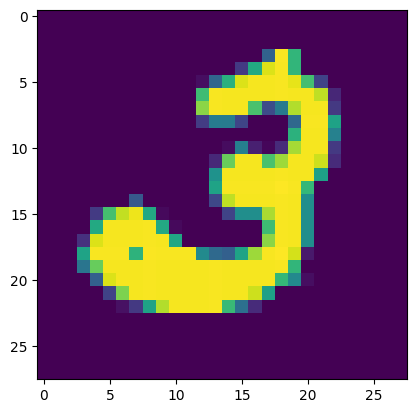

In [26]:
plt.imshow(mnist.train.images[5].reshape([28, 28]))

In [27]:
image = mnist.train.images[5].reshape([-1, 784])
feature_map = sess.run([conv1], feed_dict={X_: image})[0]

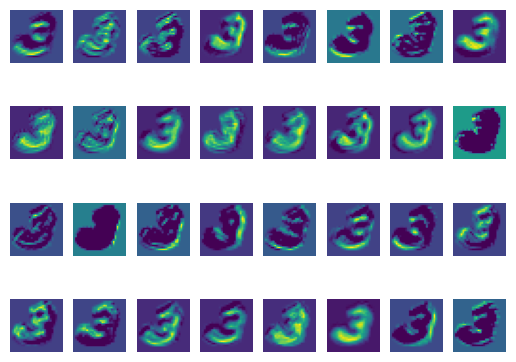

In [28]:
for i in range(32):
    feature = feature_map[:,:,:,i].reshape([28, 28])
    plt.subplot(4,8, i + 1)
    plt.imshow(feature)
    plt.axis('off')
plt.show()

Thus, the convolutional neural network uses multiple convolutional layers to extract important features from the image and feed these extracted features to a fully connected layer to classify the image.